In [1]:
import pandas as pd

annotations = pd.read_csv(
    r"G:\gnn-bert-music-context\data\magnatagatune\annotations_final.csv",
    sep="\t"
)

clip_info = pd.read_csv(
    r"G:\gnn-bert-music-context\data\magnatagatune\clip_info_final.csv",
    sep="\t"
)

print("annotations shape:", annotations.shape)
print("clip info shape:", clip_info.shape)

annotations shape: (25863, 190)
clip info shape: (31382, 10)


In [2]:
print(annotations.columns.tolist())

['clip_id', 'no voice', 'singer', 'duet', 'plucking', 'hard rock', 'world', 'bongos', 'harpsichord', 'female singing', 'clasical', 'sitar', 'chorus', 'female opera', 'male vocal', 'vocals', 'clarinet', 'heavy', 'silence', 'beats', 'men', 'woodwind', 'funky', 'no strings', 'chimes', 'foreign', 'no piano', 'horns', 'classical', 'female', 'no voices', 'soft rock', 'eerie', 'spacey', 'jazz', 'guitar', 'quiet', 'no beat', 'banjo', 'electric', 'solo', 'violins', 'folk', 'female voice', 'wind', 'happy', 'ambient', 'new age', 'synth', 'funk', 'no singing', 'middle eastern', 'trumpet', 'percussion', 'drum', 'airy', 'voice', 'repetitive', 'birds', 'space', 'strings', 'bass', 'harpsicord', 'medieval', 'male voice', 'girl', 'keyboard', 'acoustic', 'loud', 'classic', 'string', 'drums', 'electronic', 'not classical', 'chanting', 'no violin', 'not rock', 'no guitar', 'organ', 'no vocal', 'talking', 'choral', 'weird', 'opera', 'soprano', 'fast', 'acoustic guitar', 'electric guitar', 'male singer', 'ma

In [3]:
tag_counts = annotations.iloc[:, 1:-1].sum().sort_values(ascending=False)

tag_counts.head(50)

guitar          4852
classical       4272
slow            3547
techno          2954
strings         2729
drums           2598
electronic      2519
rock            2371
fast            2306
piano           2056
ambient         1956
beat            1906
violin          1826
vocal           1729
synth           1717
female          1474
indian          1395
opera           1296
male            1279
singing         1211
vocals          1184
no vocals       1158
harpsichord     1093
loud            1086
quiet           1055
flute           1025
woman           1016
male vocal      1002
no vocal         995
pop              995
soft             985
sitar            926
solo             826
man              741
classic          691
choir            688
voice            665
new age          650
dance            649
female vocal     644
male voice       644
beats            634
harp             623
cello            575
no voice         573
weird            557
country          541
metal        

In [4]:
top_50_tags = tag_counts.head(50).index
task1_data = annotations[['clip_id'] + list(top_50_tags)]

task1_data.shape

(25863, 51)

In [5]:
text_data = clip_info[['clip_id', 'title', 'artist', 'album']]

text_data.head()

,clip_id,title,artist,album
0,2,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
1,6,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
2,10,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
3,11,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
4,12,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas


In [6]:
text_data = clip_info[['clip_id', 'title', 'artist', 'album']].copy()

text_data["text"] = (
    text_data["title"] + " by " +
    text_data["artist"] + " from " +
    text_data["album"]
)

In [7]:
text_data[["clip_id", "text"]].head()

,clip_id,text
0,2,BWV54 - I Aria by American Bach Soloists from ...
1,6,BWV54 - I Aria by American Bach Soloists from ...
2,10,BWV54 - I Aria by American Bach Soloists from ...
3,11,BWV54 - I Aria by American Bach Soloists from ...
4,12,BWV54 - I Aria by American Bach Soloists from ...


In [8]:
text_data[["clip_id", "text"]].tail()

,clip_id,text
31377,58899,La Bressanina by Jacob Heringman from Blame No...
31378,58906,Lost is my Lyberty by Jacob Heringman from Bla...
31379,58907,Lost is my Lyberty by Jacob Heringman from Bla...
31380,58908,Lost is my Lyberty by Jacob Heringman from Bla...
31381,58915,A Toy for Monica Bishop by Jacob Heringman fro...


In [9]:
task1_data = text_data.merge(task1_data, on="clip_id")

task1_data.shape

(25863, 55)

In [10]:
task1_data.head()

,clip_id,title,artist,album,text,guitar,classical,slow,techno,strings,...,male voice,beats,harp,cello,no voice,weird,country,metal,female voice,choral
0,2,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,6,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,10,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,11,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [11]:
task1_data[['title', 'artist', 'album', 'text']].isnull().sum()

title     0
artist    0
album     0
text      0
dtype: int64

In [12]:
task1_data.to_csv(r"G:\gnn-bert-music-context\data\processed\task1_data.csv", index=False)

print("Task 1 dataset saved to Processed Folder")

Task 1 dataset saved to Processed Folder


In [13]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    task1_data,
    test_size=0.2,
    random_state=42
)

train_data, val_data = train_test_split(
    train_data,
    test_size=0.2,
    random_state=42
)

print("train:", len(train_data))
print("validation:", len(val_data))
print("test:", len(test_data))

train: 16552
validation: 4138
test: 5173


In [14]:
X_train = train_data["text"]
y_train = train_data[top_50_tags]

X_val = val_data["text"]
y_val = val_data[top_50_tags]

X_test = test_data["text"]
y_test = test_data[top_50_tags]

print(X_train.shape)
print(y_train.shape)

(16552,)
(16552, 50)


In [15]:
# import torch

# print(torch.__version__)
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name(0))

In [16]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

C:\Users\21101255\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
train_tokens = tokenizer(
    X_train.tolist(),
    padding=True,
    truncation=True,
    max_length=128
)

val_tokens = tokenizer(
    X_val.tolist(),
    padding=True,
    truncation=True,
    max_length=128
)

test_tokens = tokenizer(
    X_test.tolist(),
    padding=True,
    truncation=True,
    max_length=128
)

train_tokens.keys()

KeysView({'input_ids': [[101, 7146, 3385, 3686, 6519, 8928, 6710, 2063, 6151, 3321, 2080, 1011, 20022, 3401, 1006, 10093, 17545, 1007, 2011, 10093, 17545, 7146, 4068, 2013, 10093, 17545, 7146, 4068, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2026, 3203, 2063, 11265, 15985, 2140, 1005, 1055, 2598, 1006, 2520, 17845, 1007, 2011, 11810, 25293, 5035, 2013, 1996, 6261, 13911, 3215, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 24763, 12190, 6761, 2202, 7698, 1011, 6986, 10720, 2050, 1998, 23817, 11115, 2011, 20201, 8525, 2638, 17574, 2013, 9436, 2378, 1996, 12985, 2869, 1016, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 6058, 7630, 3207, 2011, 6175, 5553, 7840, 1998, 2745, 16137, 3051, 2013, 2035, 7817, 2641, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [18]:
import torch

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(train_tokens["input_ids"]),
    torch.tensor(y_train.values)
)

val_dataset = torch.utils.data.TensorDataset(
    torch.tensor(val_tokens["input_ids"]),
    torch.tensor(y_val.values)
)

test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(test_tokens["input_ids"]),
    torch.tensor(y_test.values)
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

16552
4138
5173


In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

1035
259
324


In [20]:
for i, batch in enumerate(train_loader):
    print(batch[0].shape)
    print(batch[1].shape)
    break

torch.Size([16, 59])
torch.Size([16, 50])


In [21]:
from transformers import BertForSequenceClassification
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=50,
    problem_type="multi_label_classification"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9955.71it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [22]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

print("optimizer ready")

optimizer ready


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

device

device(type='cuda')

In [24]:
import torch.nn as nn

loss_fn = nn.BCEWithLogitsLoss()

In [25]:
import numpy as np
from sklearn.metrics import f1_score

epochs = 100
patience = 5
best_micro_f1 = 0
wait = 0
train_losses = []
val_losses = []
accuracies = []
macro_f1s = []
micro_f1s = []

for i in range(epochs):
    model.train()
    train_loss = 0

    for j, batch in enumerate(train_loader):
        input_ids = batch[0].to(device)
        labels = batch[1].float().to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if j % 100 == 0:
            print("epoch:", i + 1, "batch:", j, "loss:", loss.item())

    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for j, batch in enumerate(val_loader):
            input_ids = batch[0].to(device)
            labels = batch[1].float().to(device)

            outputs = model(input_ids=input_ids)
            loss = loss_fn(outputs.logits, labels)
            val_loss += loss.item()

            predictions = torch.sigmoid(outputs.logits)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / len(val_loader)
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)

    predictions = (all_predictions >= 0.1).astype(int)

    accuracy = np.mean(all_labels == predictions)
    micro_f1 = f1_score(all_labels, predictions, average="micro")
    macro_f1 = f1_score(all_labels, predictions, average="macro")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    accuracies.append(accuracy)
    macro_f1s.append(macro_f1)
    micro_f1s.append(micro_f1)

    print("epoch:", i + 1, "train loss:", train_loss, "validation loss:", val_loss)
    print("accuracy:", accuracy, "macro-f1:", macro_f1, "micro-f1:", micro_f1)

    if micro_f1 > best_micro_f1:
        best_micro_f1 = micro_f1
        wait = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("best model saved")
    else:
        wait += 1
        print("no improvement:", wait)

    if wait >= patience:
        print("early stopping")
        break

epoch: 1 batch: 0 loss: 0.7173851132392883
epoch: 1 batch: 100 loss: 0.2641119360923767
epoch: 1 batch: 200 loss: 0.17871710658073425
epoch: 1 batch: 300 loss: 0.22224467992782593
epoch: 1 batch: 400 loss: 0.2085649073123932
epoch: 1 batch: 500 loss: 0.21630431711673737
epoch: 1 batch: 600 loss: 0.16727232933044434
epoch: 1 batch: 700 loss: 0.13988903164863586
epoch: 1 batch: 800 loss: 0.2019355297088623
epoch: 1 batch: 900 loss: 0.15338431298732758
epoch: 1 batch: 1000 loss: 0.17009598016738892
epoch: 1 train loss: 0.21593535523051802 validation loss: 0.18282883778271988
accuracy: 0.8656452392460126 macro-f1: 0.11540418420634746 micro-f1: 0.2780490338666113
best model saved
epoch: 2 batch: 0 loss: 0.22380542755126953
epoch: 2 batch: 100 loss: 0.17410124838352203
epoch: 2 batch: 200 loss: 0.20261649787425995
epoch: 2 batch: 300 loss: 0.16722168028354645
epoch: 2 batch: 400 loss: 0.15696369111537933
epoch: 2 batch: 500 loss: 0.14149509370326996
epoch: 2 batch: 600 loss: 0.17395482957363

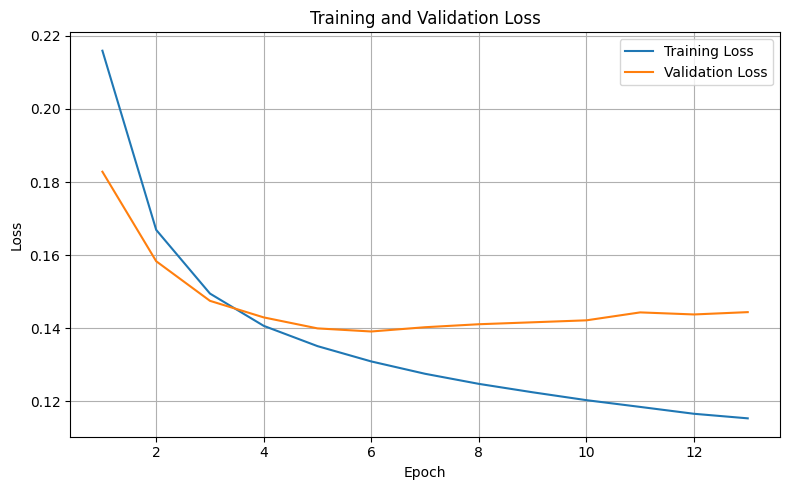

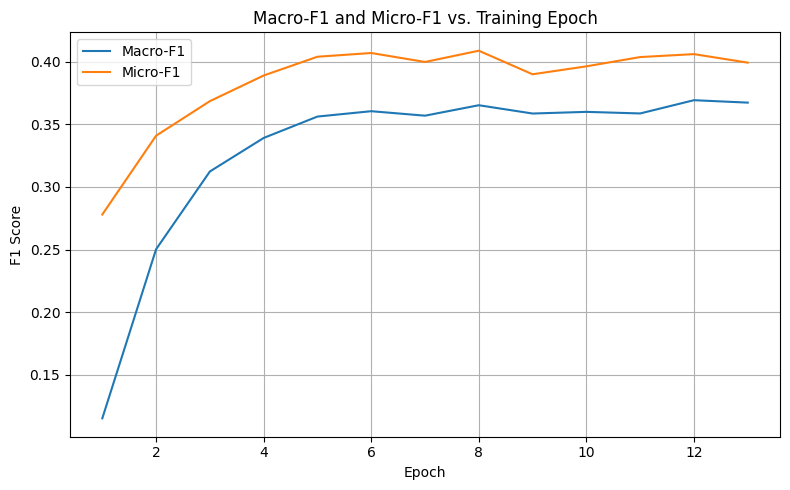

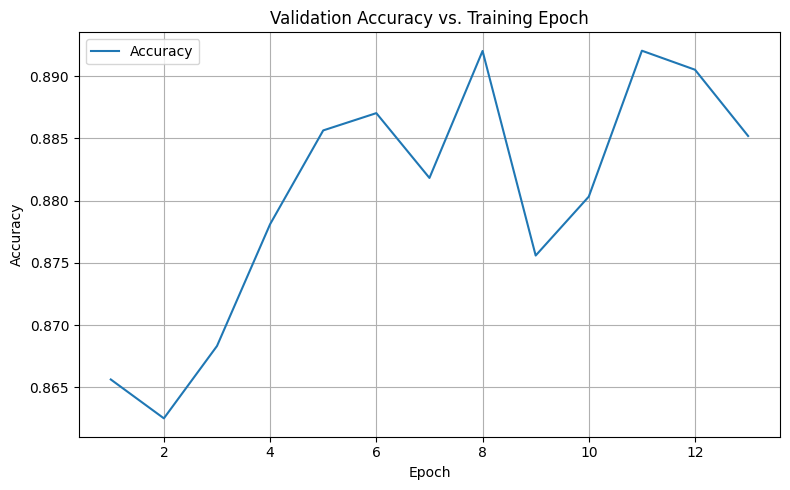

In [32]:
import matplotlib.pyplot as plt

epochs_done = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_done, train_losses, label="Training Loss")
plt.plot(epochs_done, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_done, macro_f1s, label="Macro-F1")
plt.plot(epochs_done, micro_f1s, label="Micro-F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Macro-F1 and Micro-F1 vs. Training Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_done, accuracies, label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs. Training Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
print("best model loaded")

best model loaded


In [27]:
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch[0].to(device)
        labels = batch[1].float().to(device)

        outputs = model(input_ids=input_ids)
        probabilities = torch.sigmoid(outputs.logits)

        all_predictions.extend(probabilities.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

predictions = (all_predictions >= 0.1).astype(int)

accuracy = np.mean(all_labels == predictions)
macro_f1 = f1_score(all_labels, predictions, average="macro")
micro_f1 = f1_score(all_labels, predictions, average="micro")

print("test accuracy:", accuracy)
print("test macro-f1:", macro_f1)
print("test micro-f1:", micro_f1)

test accuracy: 0.8915561569688769
test macro-f1: 0.36473162705282425
test micro-f1: 0.4074864276811931


In [36]:
tag_names = list(task1_data.columns[5:55])

for i in range(5):
    actual_tags = []
    predicted_tags = []

    for j, tag in enumerate(tag_names):
        if all_labels[i][j] == 1:
            actual_tags.append(tag)
        if predictions[i][j] == 1:
            predicted_tags.append(tag)

    print("Example:", i + 1)
    print("Text:", test_data.iloc[i]["text"])
    print("Actual tags:", actual_tags)
    print("Predicted tags:", predicted_tags)
    print()

Example: 1
Text: Part 2 by Four Stones.Net from Ridin the Faders
Actual tags: ['synth']
Predicted tags: ['techno', 'drums', 'electronic', 'fast', 'beat', 'vocal', 'synth', 'female', 'vocals', 'pop', 'dance', 'beats']

Example: 2
Text: Suite VI in Re magiore - sarabande by Vito Paternoster from CD1-Bach Cello Suites
Actual tags: ['classical', 'slow', 'strings', 'violin', 'cello']
Predicted tags: ['classical', 'slow', 'strings', 'violin', 'solo', 'classic', 'cello']

Example: 3
Text: Wet Brain by Pizzle from Party Patrol
Actual tags: ['rock', 'loud', 'metal']
Predicted tags: ['guitar', 'drums', 'rock', 'fast', 'male', 'loud', 'male vocal', 'metal']

Example: 4
Text: Lighting fly by Strojovna 07 from Mirnix
Actual tags: ['techno', 'drums', 'electronic', 'fast', 'beat', 'synth', 'pop', 'dance', 'beats']
Predicted tags: ['techno', 'drums', 'electronic', 'fast', 'beat', 'synth', 'dance', 'beats']

Example: 5
Text: smithee's second by Drop Trio from Cezanne
Actual tags: ['drums', 'piano']
Pre